# Do French stocks rally during the Tour de France? 🚴📈
### The "Grande Boucle" summer seasonal — a feel-good bump that turns out to be a mild drag

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![France--specific%3F: Not_supported](https://img.shields.io/badge/France--specific%3F-Not_supported-8b949e?style=flat-square)

Every July, France downs tools and watches the Tour de France roll from the Grand Départ to the Champs-Élysées — and every July, somebody writes the cheerful little piece: *the whole country's in a good mood, so French markets get a summer-holiday bump.* It's the calendar-window cousin of a **real** academic finding — a 2007 study showed national stock markets genuinely dip when a country's football team is knocked out of the World Cup. The Tour version borrows the mechanism (mood moves markets) and swaps in a much gentler trigger: not a win or a loss, just three weeks of bikes.

We tested it properly — all 30 editions, 1996→2025, on real French equities against Europe as a whole.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the France-vs-Europe decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 30 Tours hardcoded from Wikipedia (2020 COVID-shifted to Aug/Sep). `EWQ` = iShares MSCI France (total-return); `VGK` = Europe benchmark; `^FCHI` = CAC 40 price index (dividend-free, cross-check only). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tour_de_france_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    SUB = INC[INC["has_ar"]]                        # 2005+, VGK coverage (abnormal test)
else:
    PRICES = EV = INC = SUB = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved:", (0 if INC is None else len(INC)),
      "| with abnormal:", (0 if SUB is None else len(SUB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 30, 'n_included': 30, 'n_ar': 21, 'win_min': 15, 'win_max': 16, 'win_mean': 15.5, 'fp': 'bf542dd5cb07', 'raw_mean': -0.347, 'raw_t': -0.371, 'raw_hit': 13, 'raw_n': 30, 'raw_lo': 27.4, 'raw_hi': 60.8, 'raw_net_mean': -0.447, 'raw_net_t': -0.478, 'cac_mean': -0.325, 'cac_t': -0.376, 'cac_hit': 18, 'cac_n': 30, 'ewq_sub_mean': 0.476, 'ewq_sub_t': 0.416, 'vgk_mean': 0.681, 'vgk_t': 0.66, 'ar_mean': -0.205, 'ar_t': -0.777, 'ar_hit': 9, 'ar_n': 21, 'ar_lo': 24.5, 'ar_hi': 63.5, 'welch': -0.133, 'pl_raw_obs': -0.347, 'pl_raw_mean': 0.586, 'pl_raw_sd': 0.961, 'pl_raw_p': 0.167, 'pl_rawnet_p': 0.167, 'pl_ar_obs': -0.205, 'pl_ar_mean': -0.019, 'pl_ar_sd': 0.27, 'pl_ar_p': 0.247, 'pl_raw_right': 0.833, 'pl_ar_right': 0.752, 'car_raw': {0: 0.0, 4: -0.486, 8: -0.208, 12: -0.451, 16: -0.25}, 'car_ar': {0: 0.0, 4: -0.175, 8: -0.303, 12: -0.223, 16: -0.271}, 'y2020_raw': -5.035, 'y2020_ar': -0.963, 'raw_no20_mean': -0.185, 'raw_no20_t': -0.194, 'raw_no20_n': 29, 'syn_null_mean': 0.44, 'syn_null_sd': 0.83, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_p5_t': 3.38, 'syn_p10_t': 5.41}


real cache present: True | editions: 30 | resolved: 30 | with abnormal: 21


## The answer first

| Question | Answer |
|---|---|
| Do French stocks pop during the Tour? | **No — they dip a little.** EWQ averages **-0.35%** over the three-week window; the hit rate is **13/30**, *below* a coin flip. |
| Is that dip France-specific? | **No.** Measured against Europe, France is **-0.20%** — it slightly *lags*. The mild July softness is a whole-continent summer thing, not a French one. |
| Is it even unusual? | **No.** A random three-week window in the same tape averages **+0.59%**; the Tour window sits comfortably inside the luck cloud (placebo *p* = 0.17). |
| Could you trade it? | **You'd lose money.** Net of costs the seasonal is **-0.45%** — you'd be paying the spread to rent the summer doldrums. |

> The folklore isn't just weak here — it points the wrong way. There is no bump; there's a mild, unremarkable, entirely non-French summer softness.

## 1 · The claim

> *"For three weeks every July the whole of France is glued to the Tour de France — a wave of national feel-good, tourism and summer-holiday spending that lifts sentiment enough to show up as a bump in French stocks."*

It rides on real science: Edmans, García & Norli (2007) found national markets genuinely *fall* the day after a country is **eliminated** from the football World Cup — sports sentiment really does move money. The Tour borrows that mood-to-market idea but stretches it onto a gentle three-week *calendar window* with no win-or-lose shock. Nobody has ever formally tested it. We did.

## 2 · So what?

If real, it would be a delightful little seasonal: buy the France ETF the day before the Grand Départ, sell after the Champs-Élysées finale, pocket the national good mood. And because the Tour dates are fixed a *year* in advance, there's no guesswork about timing — it would be one of the cleanest calendar trades imaginable. So: is it there?

## 3 · How would we even know?

- **The calendar.** All **30** Tours 1996→2025, hardcoded with each Grand Départ and final-stage date (2020 was COVID-shifted from July to Aug/Sep — a handy accidental experiment).
- **The market.** `EWQ` (iShares MSCI France) over the race window, both **raw** and **abnormal** vs `VGK`, a broad Europe benchmark — because July is the heart of the *"Sell in May and go away"* summer-weakness window, any raw dip has to be checked against Europe before we call it French.
- **The honesty checks.** A random-window placebo (is a July-Tour window any different from an ordinary three weeks?), a CAC-40 cross-check, the 2020 race-vs-calendar probe, and a costed trade you could *actually* have placed.

## 4 · The teardown — let's actually look

**First, the headline: the "bump" is a mild drag.**

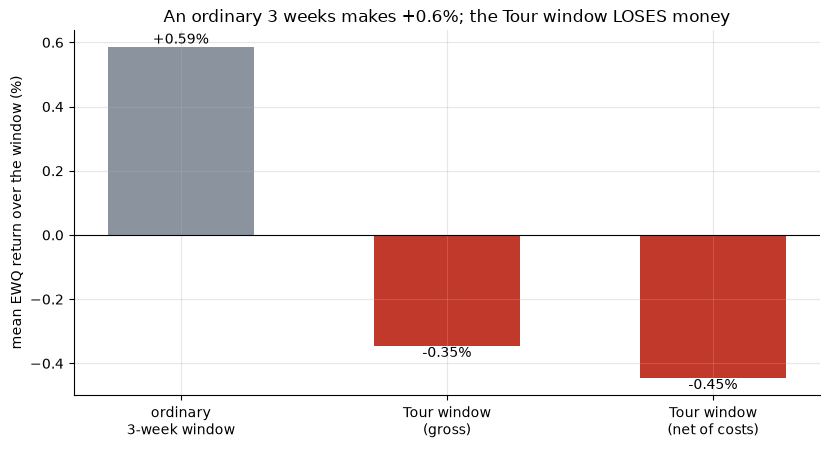

Tour gross -0.35%  net -0.45%  vs ordinary window +0.59%


In [2]:
if HAVE_REAL:
    raw = st.one_sample_t(INC['raw_ret'].values)['mean']*100
    net = st.one_sample_t(INC['raw_net'].values)['mean']*100
    ordn = R['pl_raw_mean']  # canonical placebo mean (results.md)
else:
    raw, net, ordn = R['raw_mean'], R['raw_net_mean'], R['pl_raw_mean']
fig, ax = plt.subplots(figsize=(8.4, 4.6))
bars = ax.bar(['ordinary\n3-week window', 'Tour window\n(gross)', 'Tour window\n(net of costs)'], [ordn, raw, net],
              color=[GREY, RED, RED], width=.55)
for b, v in zip(bars, [ordn, raw, net]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v), ha='center',
                va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean EWQ return over the window (%)')
ax.set_title('An ordinary 3 weeks makes +0.6%; the Tour window LOSES money')
plt.tight_layout(); plt.show()
print(f'Tour gross {raw:+.2f}%  net {net:+.2f}%  vs ordinary window {ordn:+.2f}%')

Buy French stocks for the three weeks of the Tour and on average you're down **-0.35%** before costs, **-0.45%** after — while an *ordinary* three-week stretch in the same tape makes **+0.59%**. That's not a feel-good bump; that's the summer doldrums. Which raises the obvious question: **is that dip French at all, or is all of Europe soft in July?**

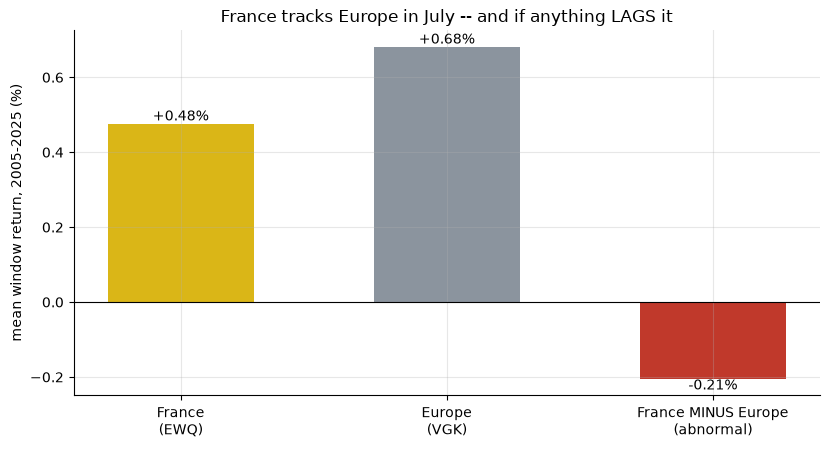

France +0.48%  Europe +0.68%  abnormal -0.21%


In [3]:
if HAVE_REAL:
    ewq = st.one_sample_t(SUB['raw_ret'].values)['mean']*100
    vgk_rets = []
    common = PRICES['EWQ'].index.intersection(PRICES['VGK'].index).sort_values()
    for _, r in SUB.iterrows():
        e, x = st._window_positions(common, r['grand_depart'], r['final_stage'])
        vgk_rets.append(PRICES['VGK'].loc[common[x]]/PRICES['VGK'].loc[common[e]]-1)
    vgk = np.mean(vgk_rets)*100
    ar = st.one_sample_t(SUB['ar'].values)['mean']*100
else:
    ewq, vgk, ar = R['ewq_sub_mean'], R['vgk_mean'], R['ar_mean']
fig, ax = plt.subplots(figsize=(8.4, 4.6))
bars = ax.bar(['France\n(EWQ)', 'Europe\n(VGK)', 'France MINUS Europe\n(abnormal)'],
              [ewq, vgk, ar], color=[AMBER, GREY, RED], width=.55)
for b, v in zip(bars, [ewq, vgk, ar]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v), ha='center',
                va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean window return, 2005-2025 (%)')
ax.set_title('France tracks Europe in July -- and if anything LAGS it')
plt.tight_layout(); plt.show()
print(f'France {ewq:+.2f}%  Europe {vgk:+.2f}%  abnormal {ar:+.2f}%')

There it is. Over the era we can benchmark (2005→), France makes **+0.48%** during the Tour and Europe makes **+0.68%** — so France doesn't *beat* Europe, it **lags** by **-0.20%**. Whatever French stocks do in July, they do it because they're part of Europe, not because of a bike race. The one number that could have been a Tour effect — the abnormal, France-minus-Europe return — is the emptiest of the lot.

**And the shape? A national-mood story predicts *some* pattern. There isn't one:**

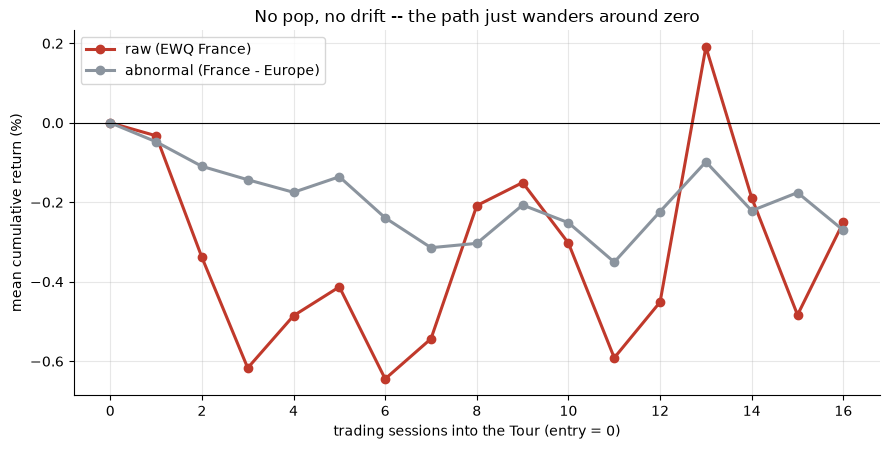

In [4]:
if HAVE_REAL:
    cp_raw = st.car_path(EV, PRICES, 'raw', 16)
    cp_ar = st.car_path(EV, PRICES, 'ar', 16)
    days = list(cp_raw.index); rs = list(cp_raw.values*100); as_ = list(cp_ar.values*100)
else:
    days = sorted(R['car_raw']); rs = [R['car_raw'][k] for k in days]
    as_ = [R['car_ar'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.plot(days, rs, color=RED, lw=2.2, marker='o', label='raw (EWQ France)')
ax.plot(days, as_, color=GREY, lw=2.2, marker='o', label='abnormal (France - Europe)')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading sessions into the Tour (entry = 0)')
ax.set_ylabel('mean cumulative return (%)')
ax.set_title('No pop, no drift -- the path just wanders around zero')
ax.legend(); plt.tight_layout(); plt.show()

A genuine feel-good bump should show up as *something* — an early pop that holds, a steady drift. This is neither: the path drops a bit in the first week, wobbles, and ends slightly negative, with the France-minus-Europe line flat-to-negative the whole way. **Finally, is the Tour window even unusual?**

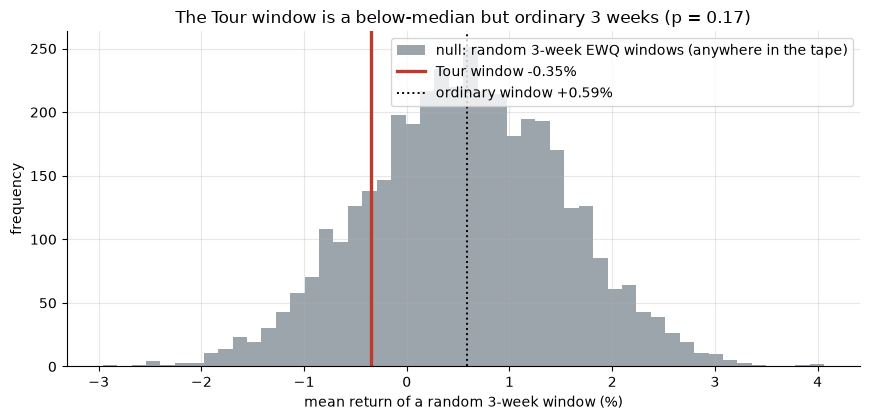

observed -0.35%  vs placebo +0.59% (sd 0.96%)  left-tail p = 0.167; 83% of random windows BEAT the Tour


In [5]:
rng = np.random.default_rng(732)
draws = rng.normal(R['pl_raw_mean'], R['pl_raw_sd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random 3-week EWQ windows (anywhere in the tape)')
ax.axvline(R['raw_mean'], c=RED, lw=2.4, label=f"Tour window {R['raw_mean']:+.2f}%")
ax.axvline(R['pl_raw_mean'], c='k', ls=':', lw=1.4, label=f"ordinary window {R['pl_raw_mean']:+.2f}%")
ax.set_xlabel('mean return of a random 3-week window (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The Tour window is a below-median but ordinary 3 weeks (p = {R["pl_raw_p"]:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['raw_mean']:+.2f}%  vs placebo {R['pl_raw_mean']:+.2f}% "
      f"(sd {R['pl_raw_sd']:.2f}%)  left-tail p = {R['pl_raw_p']:.3f}; "
      f"{R['pl_raw_right']*100:.0f}% of random windows BEAT the Tour")

The Tour window is soft — but so are plenty of random three-week stretches. **83%** of random windows actually *beat* it, and the gap isn't statistically unusual (placebo *p* = 0.17). It's a below-average but utterly ordinary patch of summer.

## 5 · The verdict

- **Signal — None.** The raw seasonal is a mild *negative* (-0.35%, *t* = -0.37), the France-specific abnormal is *also* negative (-0.20%, *t* = -0.78), the hit rate is below a coin flip, and neither is distinguishable from an ordinary three weeks. There is nothing here, in either direction.
- **Tradability — Mirage.** No positive edge exists to trade — the seasonal is **-0.45%** net of costs. "Buy French stocks during the Tour" is a systematic small loss.
- **A France-specific effect? — Not supported.** France doesn't beat Europe during the Tour (it slightly lags). The mild July softness is ordinary pan-European summer beta — the folklore mis-attributes a whole-continent calendar non-event to a bike race.

## 6 · Going further 🚪

- **This is the cleanest kind of null.** No surprise, no information lag, a date fixed a year ahead, 30 events — and *still* nothing, because the premise collided with a bigger, real seasonal ("Sell in May") and evaporated the moment we netted out Europe. Sometimes the honest answer is just "no," and it's worth writing down.
- **Sibling studies:** the [Eurovision effect](../../708-eurovision-effect/) (the same national-mood folklore, but keyed to a *surprise* result across a per-country panel), the [World Cup effect](../../235-world-cup-effect/) (the real Edmans mechanism), the [Super Bowl indicator](../../158-super-bowl/) and [World Series effect](../../709-world-series-effect/) — every one a national-mood claim, tested the same honest way.

*Think there's a real Tour effect hiding in the tourism/leisure/consumer sub-sector, or intraday around the Champs-Élysées finale? Bring a bigger, cleaner sample and a net, placebo-surviving edge — we'll publish the teardown.*